# 🤖 AI & Margin: When Does AI Help and When Does It Hurt?
**ML Project SEA – A.Y. 2025/2026 | Alkemy AI Productivity**

> **Research Question:** Beyond which AI usage threshold does rework destroy profit margin?

---

**Pipeline overview:**
1. Data Loading & Cleaning  
2. Feature Engineering  
3. Exploratory Data Analysis (EDA)  
4. AI vs No-AI Comparison  
5. Trade-off Analysis (Speed vs Quality)  
6. Non-linear Effect of AI on Margin  
7. Threshold Detection 🔥  
8. Loss & Hidden Cost Analysis  
9. Mechanism Explanation  
10. Robustness Checks  
11. Advanced Insights  
12. Business Decision 🔥

## 1. Imports & Setup

In [1]:
import os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import missingno as msno
from scipy import stats
import statsmodels.api as sm

warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': '#0f1117',
    'axes.facecolor': '#1a1d27',
    'axes.edgecolor': '#3a3d4a',
    'axes.labelcolor': '#e0e0e0',
    'axes.titlecolor': '#ffffff',
    'xtick.color': '#a0a0a0',
    'ytick.color': '#a0a0a0',
    'text.color': '#e0e0e0',
    'grid.color': '#2a2d3a',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'legend.facecolor': '#1a1d27',
    'legend.edgecolor': '#3a3d4a',
    'font.family': 'sans-serif',
})
PALETTE = ['#7c6ae6', '#e06c75', '#56b6c2', '#e5c07b', '#98c379', '#d19a66']
SEA_BLUE   = '#7c6ae6'
SEA_RED    = '#e06c75'
SEA_GREEN  = '#98c379'
SEA_YELLOW = '#e5c07b'
SEA_CYAN   = '#56b6c2'

HERE     = os.path.abspath(os.path.dirname('')) if '__file__' not in dir() else os.path.dirname(__file__)
DATA_DIR = os.path.join(HERE, 'data')
PATH     = os.path.join(DATA_DIR, 'ai_productivity_dataset_final.csv')
print('Path:', PATH)
print('Dependencies loaded ✓')

Path: /Users/andreamammano/Machine Learning/ML_Project_SEA_815441/data/ai_productivity_dataset_final.csv
Dependencies loaded ✓


## 2. Data Loading & Overview

In [2]:
df_raw = pd.read_csv(PATH)
print(f"Shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}")
df_raw.head(3)

Shape: (3248, 34)
Columns: ['task_id', 'client', 'project_id', 'client_tier', 'team', 'task_type', 'seniority', 'task_complexity_score', 'brief_quality_score', 'deadline_pressure', 'scope_change_flag', 'pricing_model', 'created_at', 'delivered_at', 'sla_days', 'sla_breach', 'hours_spent', 'billable_hours', 'ai_usage_pct', 'ai_assisted', 'revisions', 'errors', 'rework_hours', 'outcome_score', 'revenue', 'cost', 'profit', 'created_by', 'updated_at', 'task_status', 'workflow_stage', 'jira_ticket', 'legacy_ai_flag', 'content_version']


,task_id,client,project_id,client_tier,team,task_type,seniority,task_complexity_score,brief_quality_score,deadline_pressure,...,revenue,cost,profit,created_by,updated_at,task_status,workflow_stage,jira_ticket,legacy_ai_flag,content_version
0,T00000,Client_F,P038,mid,Content,report,junior,2,3.0,high,...,498.11,346.17,151.94,user_096,2025-11-28,review,finalized,JIRA-49014,true,v1
1,T00001,Client_H,P028,low,Paid Media,release,junior,1,2.0,medium,...,847.01,343.18,503.83,user_058,2026-01-26,delivered,client_review,JIRA-84793,false,v1
2,T00002,Client_D,P009,low,Design,dev,junior,3,4.0,medium,...,1374.07,365.02,1009.05,user_074,2025-09-17,in_progress,qa,JIRA-42485,true,v2


In [3]:
df_raw.describe()

,task_complexity_score,brief_quality_score,scope_change_flag,sla_days,sla_breach,hours_spent,billable_hours,ai_usage_pct,revisions,errors,rework_hours,outcome_score,revenue,cost,profit
count,3248.000000,3179.000000,3248.000000,3212.000000,3248.000000,3248.00000,3166.000000,3104.000000,3248.000000,3248.000000,3176.000000,3115.000000,3248.000000,3248.000000,3248.000000
mean,2.868842,3.183391,0.139163,5.012765,0.398091,13.05551,8.431563,0.361717,3.007697,1.014163,2.437543,68.856918,1120.571260,771.308146,349.263114
std,1.196459,1.211712,0.346169,2.520330,0.489580,11.55750,4.783216,0.199391,1.804829,1.042868,2.911421,12.642211,841.649433,584.269354,888.072715
min,1.000000,1.000000,0.000000,2.000000,0.000000,0.02000,-1.900000,0.000000,0.000000,0.000000,0.000000,9.000000,45.000000,77.850000,-8510.549511
25%,2.000000,2.000000,0.000000,3.000000,0.000000,7.91000,5.080000,0.200000,2.000000,0.000000,1.110000,60.870000,646.312500,440.805000,-2.610000
50%,3.000000,3.000000,0.000000,5.000000,0.000000,11.11500,7.535000,0.340000,3.000000,1.000000,1.810000,69.400000,966.430000,649.065000,254.645000
75%,4.000000,4.000000,0.000000,7.000000,1.000000,15.34500,10.687500,0.500000,4.000000,2.000000,2.950000,77.610000,1364.700000,941.145000,590.400000
max,5.000000,5.000000,1.000000,10.000000,1.000000,263.60018,47.020000,0.930000,11.000000,7.000000,57.517012,100.000000,14927.204324,9409.639511,14006.644324


## 3. Data Cleaning

Steps applied:
1. **Deduplication** on `task_id`
2. **Team normalization** (case + typo fix)
3. **Date parsing** (`created_at`, `delivered_at`)
4. **Legacy AI flag** (`true/false/unknown` → boolean/NaN)
5. **Missing value imputation** (median for numerics, mode for categoricals)
6. **Outlier capping** (IQR × 3 on `profit`, `hours_spent`, `rework_hours`)

In [4]:
df = df_raw.copy()

# ── 3.1 Deduplication ─────────────────────────────────────────────────────
before = len(df)
df = df.drop_duplicates(subset='task_id')
print(f"Duplicates removed: {before - len(df)}")

# ── 3.2 Normalize 'team' column ───────────────────────────────────────────
team_map = {
    'seo': 'SEO', 'SEO ': 'SEO',
    'media': 'Media', 'MEDIA': 'Media', 'Paid Media': 'Media',
    'content': 'Content', 'CONTENT': 'Content', 'Contennt': 'Content',
    'design': 'Design', 'DESIGN': 'Design', 'Desgn': 'Design',
}
df['team'] = df['team'].replace(team_map)
print("Teams:", sorted(df['team'].unique()))

# ── 3.3 Date parsing ──────────────────────────────────────────────────────
df['created_at']   = pd.to_datetime(df['created_at'],   errors='coerce')
df['delivered_at'] = pd.to_datetime(df['delivered_at'],  errors='coerce')
df['updated_at']   = pd.to_datetime(df['updated_at'],    errors='coerce')

# ── 3.4 Legacy AI flag ────────────────────────────────────────────────────
df['legacy_ai_flag'] = df['legacy_ai_flag'].map({'true': True, 'false': False})
# 'unknown' becomes NaN — correct behaviour

# ── 3.5 Missing value imputation ─────────────────────────────────────────
num_cols_impute = ['ai_usage_pct', 'outcome_score', 'rework_hours',
                   'brief_quality_score', 'sla_days']
for col in num_cols_impute:
    median = df[col].median()
    n_filled = df[col].isna().sum()
    df[col] = df[col].fillna(median)
    print(f"  {col}: filled {n_filled} NaN → median={median:.3f}")

# billable_hours: impute with hours_spent * 0.85
mask_bh = df['billable_hours'].isna()
df.loc[mask_bh, 'billable_hours'] = df.loc[mask_bh, 'hours_spent'] * 0.85
print(f"  billable_hours: filled {mask_bh.sum()} NaN")

# ── 3.6 Outlier capping (IQR × 3) ────────────────────────────────────────
def cap_iqr(series, k=3):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - k * iqr, q3 + k * iqr
    return series.clip(lo, hi)

for col in ['profit', 'hours_spent', 'rework_hours', 'revenue', 'cost']:
    df[col] = cap_iqr(df[col])

print(f"\nClean shape: {df.shape}")
df.isnull().sum()[df.isnull().sum() > 0]

Duplicates removed: 48
Teams: ['Content', 'Design', 'Media', 'SEO']
  ai_usage_pct: filled 142 NaN → median=0.340
  outcome_score: filled 130 NaN → median=69.405
  rework_hours: filled 71 NaN → median=1.810
  brief_quality_score: filled 69 NaN → median=3.000
  sla_days: filled 35 NaN → median=5.000
  billable_hours: filled 81 NaN

Clean shape: (3200, 34)


delivered_at       38
jira_ticket       331
legacy_ai_flag    333
dtype: int64

### 3b. Missing Value Pattern

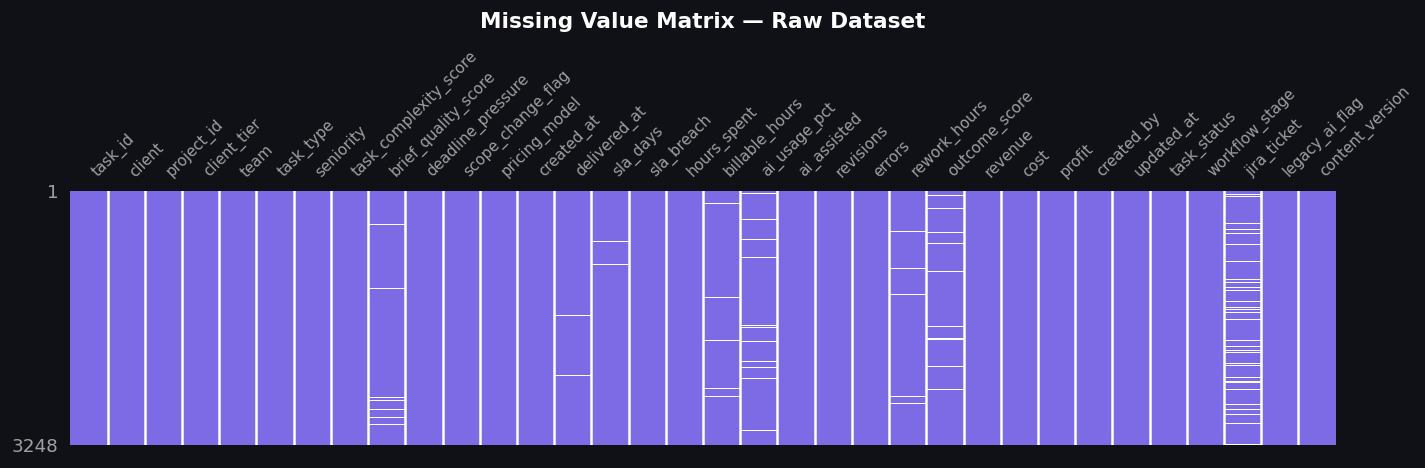

In [5]:
fig, ax = plt.subplots(figsize=(12, 4))
msno.matrix(df_raw, ax=ax, color=(0.49, 0.42, 0.90), fontsize=9)
ax.set_title("Missing Value Matrix — Raw Dataset", fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

## 4. Feature Engineering

| Feature | Formula | Purpose |
|---------|---------|---------|
| `margin_pct` | `profit / revenue × 100` | normalised profitability |
| `ai_flag` | `ai_usage_pct > 0` | binary AI usage |
| `rework_rate` | `rework_hours / hours_spent` | quality degradation proxy |
| `billable_ratio` | `billable_hours / hours_spent` | billing efficiency |
| `cost_per_hour` | `cost / hours_spent` | cost intensity |
| `duration_days` | `delivered_at - created_at` | delivery time |
| `ai_bucket` | 5 bins on `ai_usage_pct` | threshold analysis |

In [6]:
df['margin_pct']     = df['profit'] / df['revenue'].replace(0, np.nan) * 100
df['ai_flag']        = df['ai_usage_pct'] > 0
df['rework_rate']    = df['rework_hours'] / df['hours_spent'].replace(0, np.nan)
df['billable_ratio'] = df['billable_hours'] / df['hours_spent'].replace(0, np.nan)
df['cost_per_hour']  = df['cost'] / df['hours_spent'].replace(0, np.nan)
df['duration_days']  = (df['delivered_at'] - df['created_at']).dt.days

# AI usage buckets
bins   = [0, 0.20, 0.40, 0.60, 0.80, 1.01]
labels = ['0–20%', '20–40%', '40–60%', '60–80%', '80–100%']
df['ai_bucket'] = pd.cut(df['ai_usage_pct'], bins=bins, labels=labels, right=False)

# No-AI bucket explicitly
df.loc[df['ai_usage_pct'] == 0, 'ai_bucket'] = '0–20%'

print("New features added:")
print(df[['margin_pct','ai_flag','rework_rate','billable_ratio',
          'cost_per_hour','duration_days','ai_bucket']].describe())

New features added:
        margin_pct  rework_rate  billable_ratio  cost_per_hour  duration_days
count  3200.000000  3200.000000     3200.000000    3200.000000    3162.000000
mean     15.926967     0.359771        1.069572     105.463439       4.476597
std      67.377265     3.077229        6.571249     841.818454       1.803084
min   -1673.680230     0.000000       -0.337374       6.376261      -3.000000
25%      -0.234638     0.092037        0.570811      47.058325       3.000000
50%      29.087767     0.164947        0.695570      58.156745       5.000000
75%      51.125554     0.287938        0.813586      71.826768       6.000000
max      94.877334   138.666667      220.000000   35213.500000      10.000000


## 5. Exploratory Data Analysis

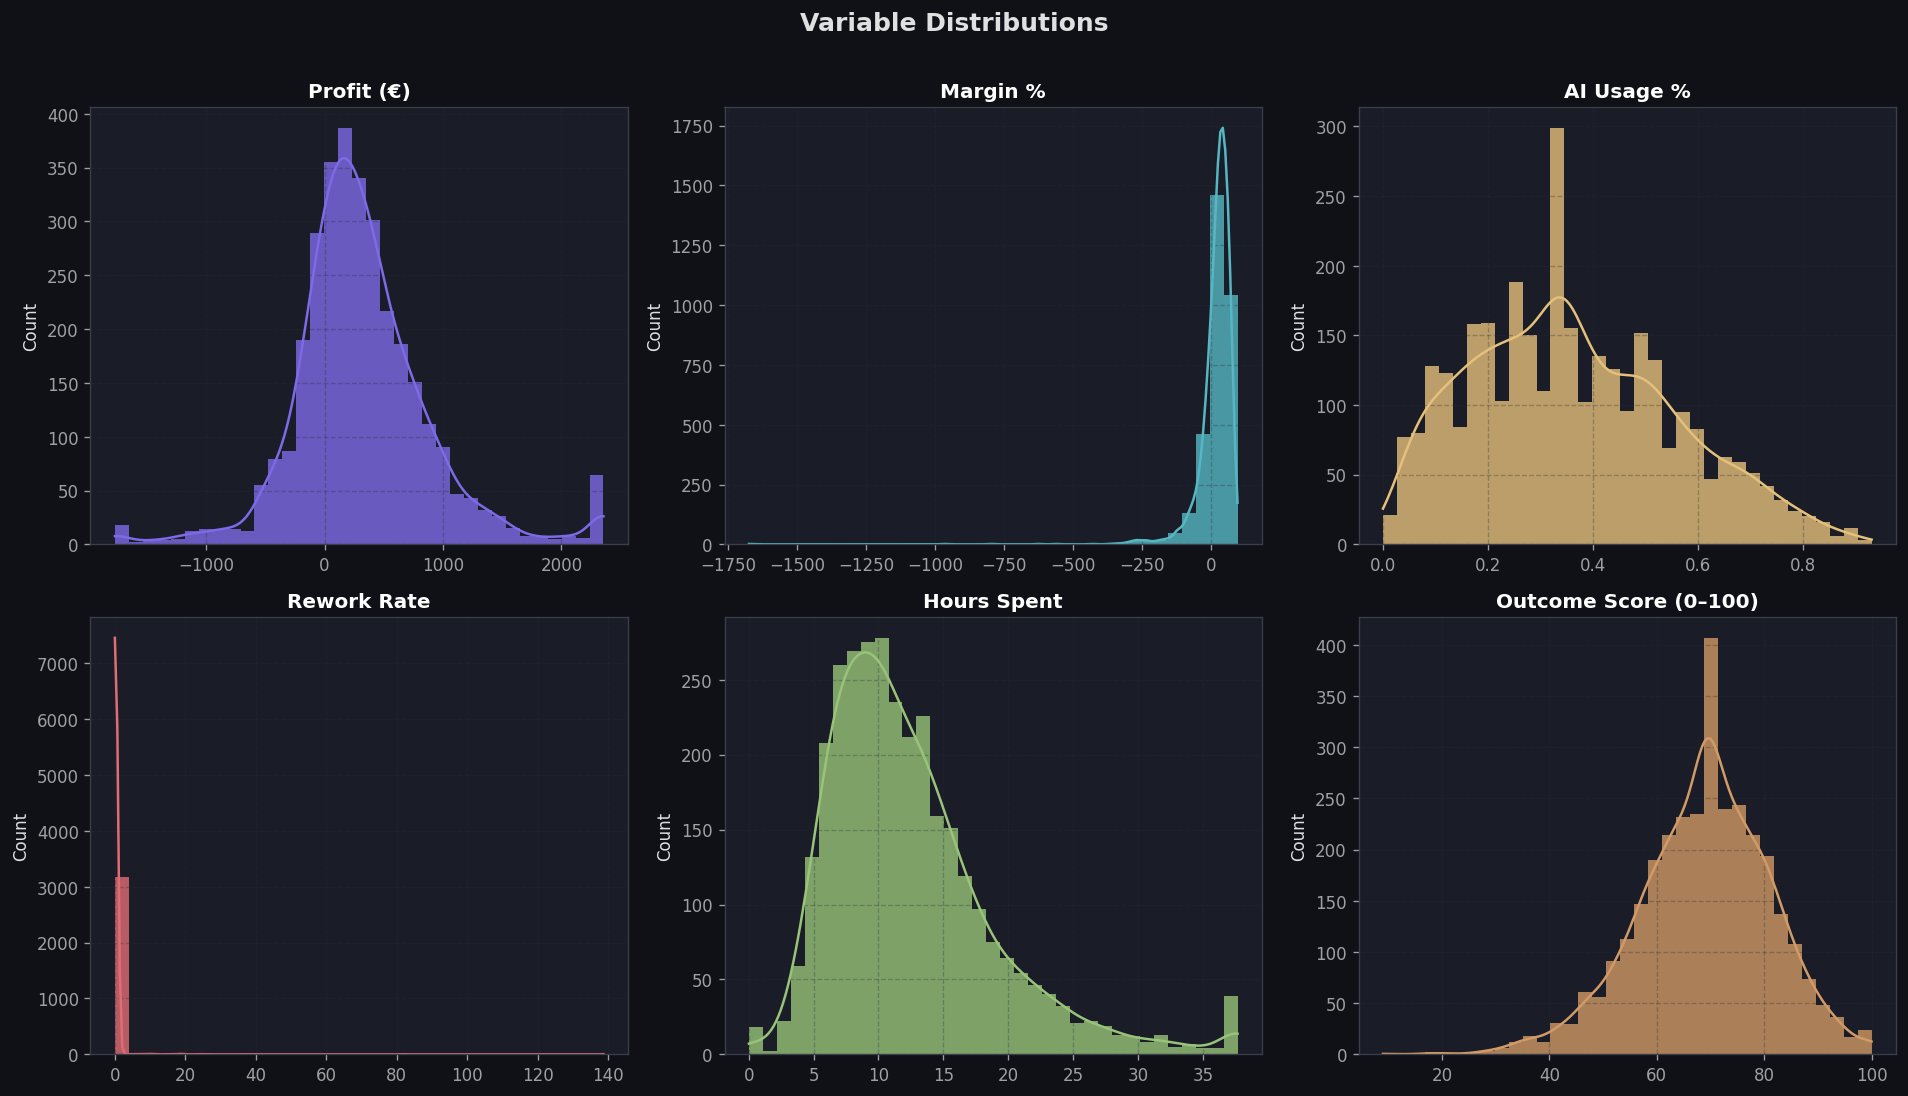

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

hist_cfg = dict(kde=True, color=SEA_BLUE, alpha=0.85, edgecolor='none')

variables = [
    ('profit',       'Profit (€)',            SEA_BLUE),
    ('margin_pct',   'Margin %',              SEA_CYAN),
    ('ai_usage_pct', 'AI Usage %',            SEA_YELLOW),
    ('rework_rate',  'Rework Rate',           SEA_RED),
    ('hours_spent',  'Hours Spent',           SEA_GREEN),
    ('outcome_score','Outcome Score (0–100)', '#d19a66'),
]

for ax, (col, label, col_color) in zip(axes, variables):
    sns.histplot(df[col].dropna(), bins=35, kde=True, ax=ax,
                 color=col_color, alpha=0.8, edgecolor='none')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.grid(True, alpha=0.3)

plt.suptitle("Variable Distributions", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

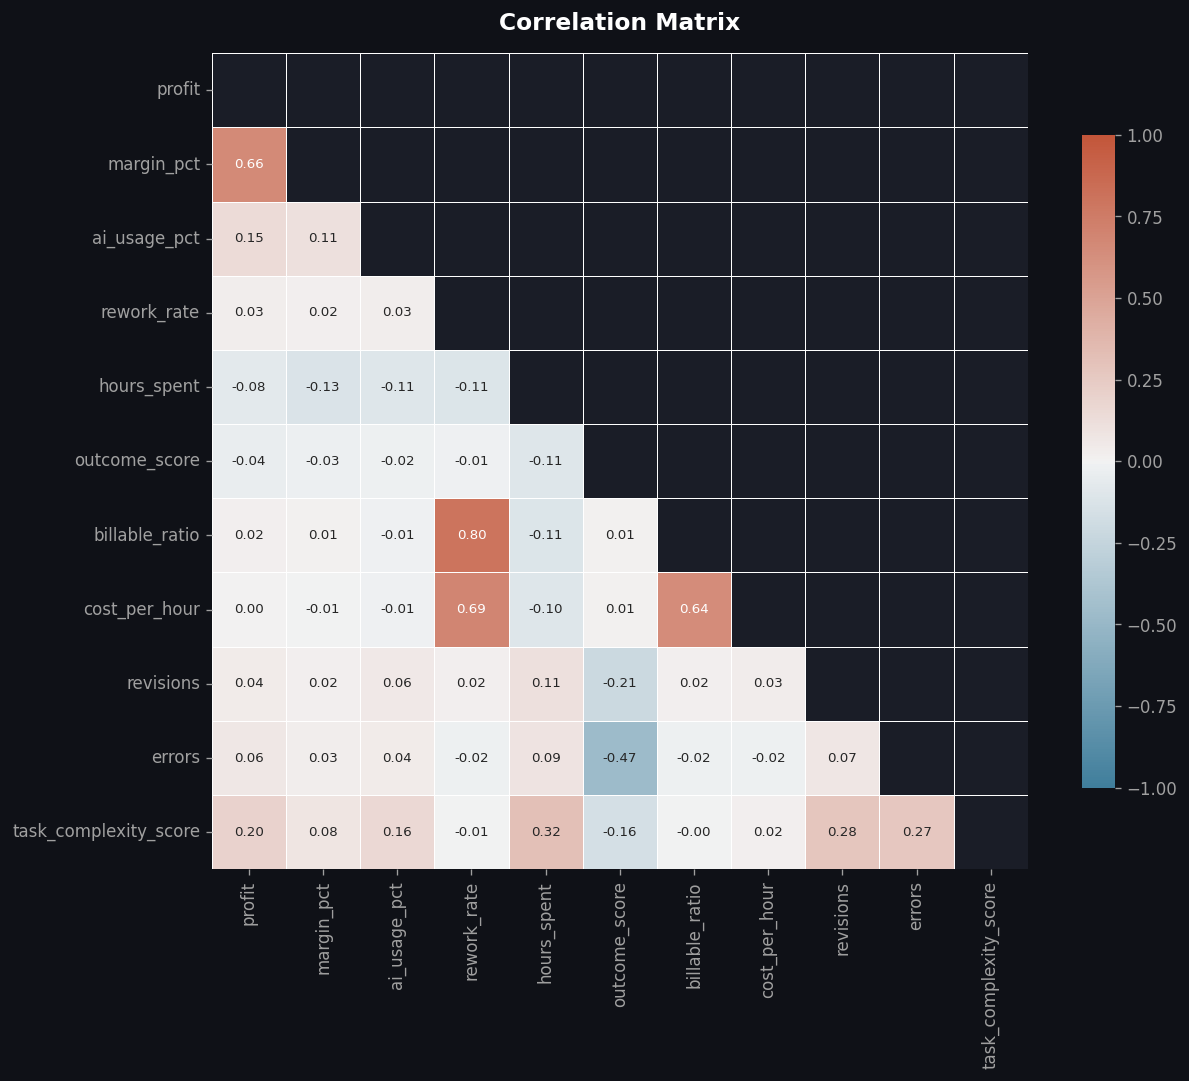

In [8]:
corr_cols = ['profit', 'margin_pct', 'ai_usage_pct', 'rework_rate',
             'hours_spent', 'outcome_score', 'billable_ratio',
             'cost_per_hour', 'revisions', 'errors', 'task_complexity_score']

corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=1, vmin=-1, center=0,
            annot=True, fmt='.2f', annot_kws={'size': 8},
            square=True, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title("Correlation Matrix", fontsize=14, fontweight='bold', pad=14)
plt.tight_layout()
plt.show()

## 6. AI vs No-AI Comparison

In [9]:
metrics = {
    'Profit (€)':      'profit',
    'Margin %':        'margin_pct',
    'Hours Spent':     'hours_spent',
    'Rework Rate':     'rework_rate',
    'Outcome Score':   'outcome_score',
    'Revisions':       'revisions',
}

comparison = df.groupby('ai_flag')[[v for v in metrics.values()]].agg(['mean','median','std'])
comparison.index = ['No AI', 'With AI']
print(comparison.round(3))

# Statistical significance
print("\n── T-test (Welch) ──")
for label, col in metrics.items():
    ai  = df.loc[df['ai_flag'], col].dropna()
    nai = df.loc[~df['ai_flag'], col].dropna()
    t, p = stats.ttest_ind(ai, nai, equal_var=False)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    print(f"  {label:20s}: t={t:+.3f}  p={p:.4f}  {sig}")

          profit                   margin_pct                 hours_spent  \
            mean   median      std       mean  median     std        mean   
No AI    322.515  322.515   94.109     42.121  42.121  18.425       8.210   
With AI  320.600  255.500  589.246     15.911  29.076  67.394      12.483   

                       rework_rate               outcome_score          \
         median    std        mean median    std          mean  median   
No AI     8.210  2.616       0.227  0.227  0.257        57.295  57.295   
With AI  11.105  6.496       0.360  0.165  3.078        68.908  69.405   

                revisions                
            std      mean median    std  
No AI     3.104     4.000    4.0  0.000  
With AI  12.355     3.011    3.0  1.806  

── T-test (Welch) ──
  Profit (€)          : t=-0.028  p=0.9817  ns
  Margin %            : t=-2.003  p=0.2915  ns
  Hours Spent         : t=+2.305  p=0.2590  ns
  Rework Rate         : t=+0.700  p=0.5957  ns
  Outcome Score 

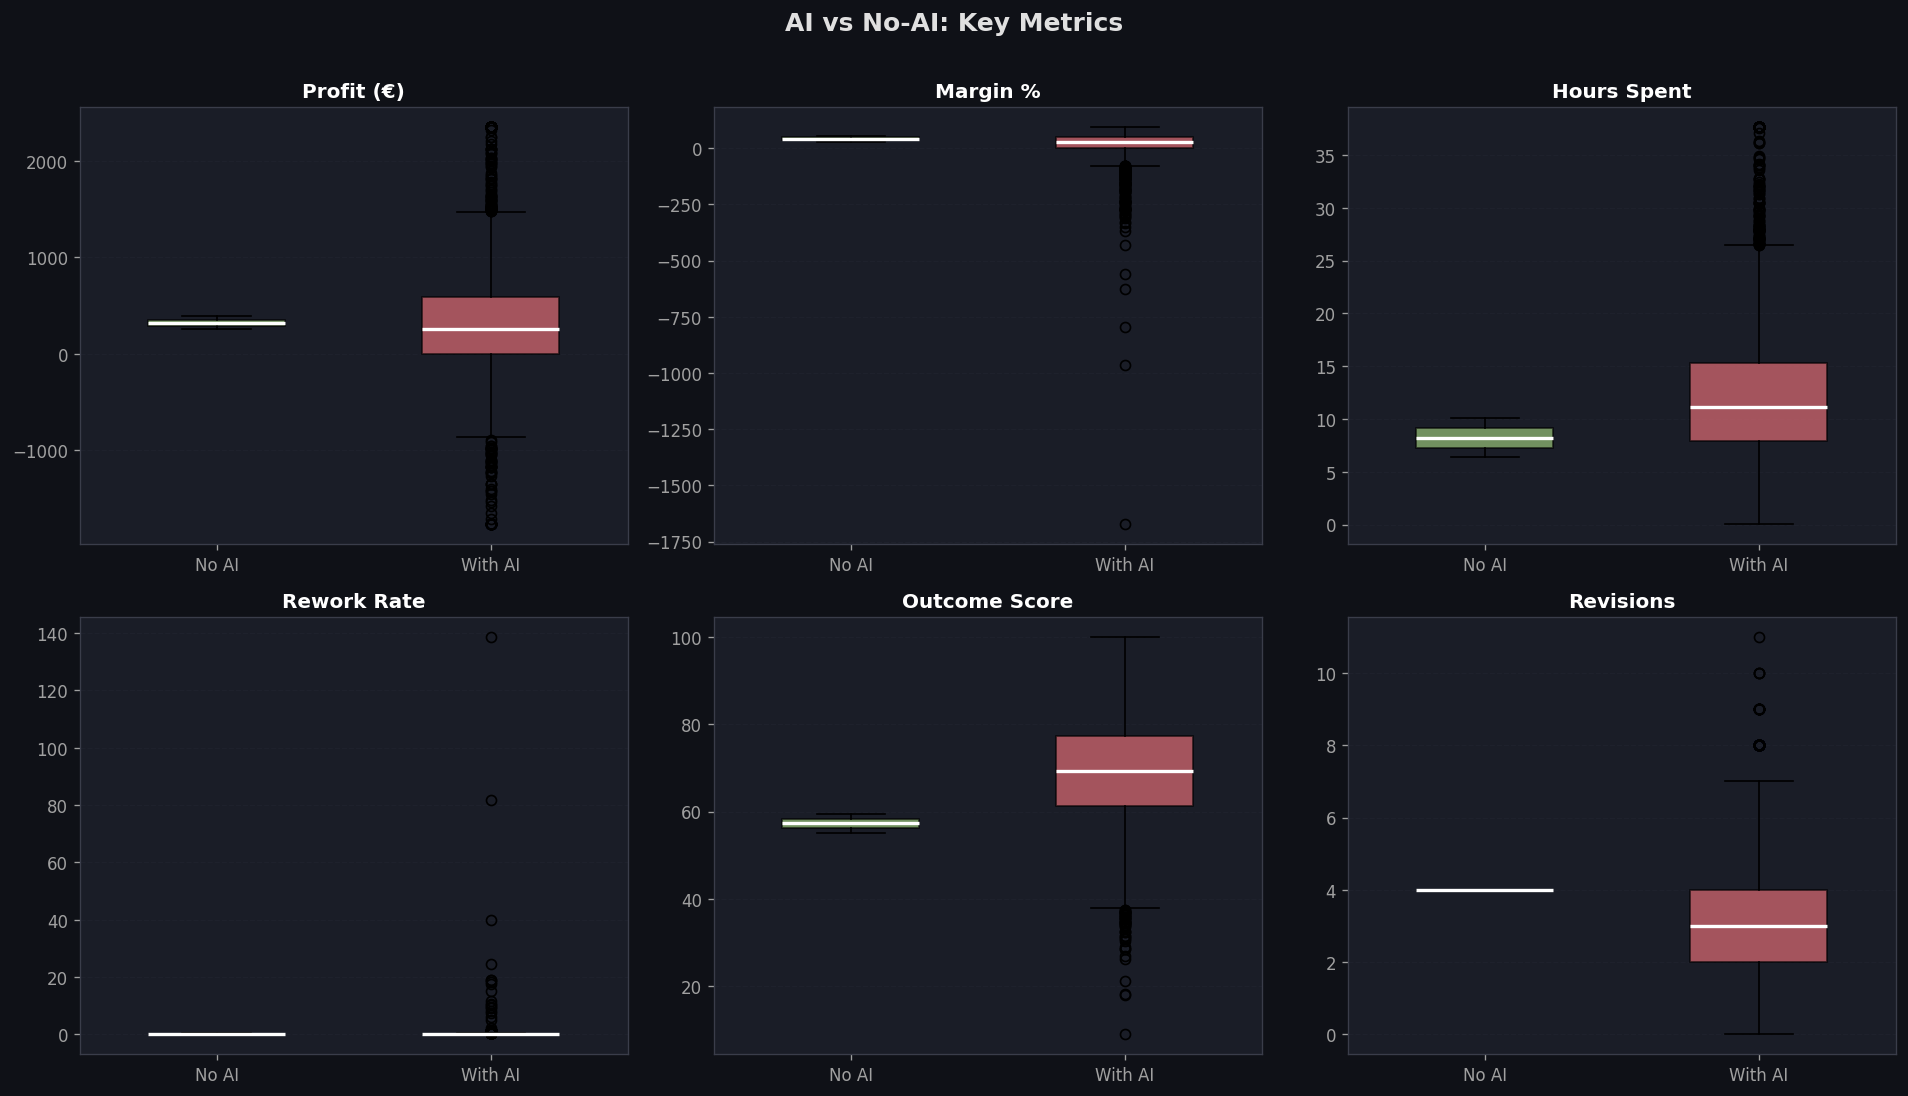

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
colors = [SEA_GREEN, SEA_RED]

for ax, (label, col) in zip(axes, metrics.items()):
    data = [df.loc[~df['ai_flag'], col].dropna(),
            df.loc[df['ai_flag'],  col].dropna()]
    bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                    medianprops=dict(color='white', linewidth=2))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticklabels(['No AI', 'With AI'])
    ax.set_title(label, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle("AI vs No-AI: Key Metrics", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 7. Trade-off Analysis: Speed vs Quality

We examine whether AI improves both speed (↓ hours) and quality (↑ outcome_score / ↓ rework)
or whether gains in one dimension come at the cost of the other.

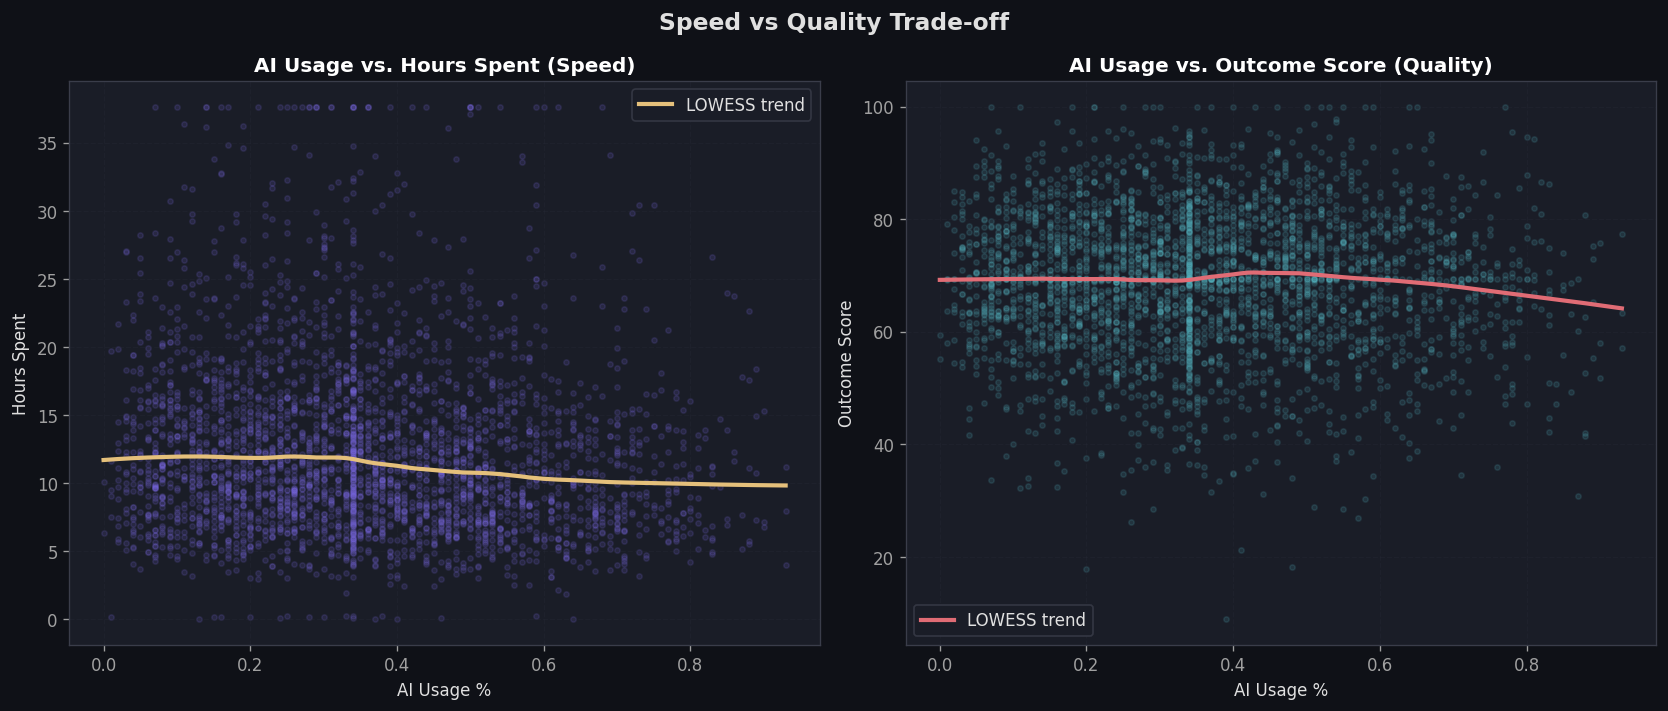

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Speed: AI usage vs hours_spent
ax = axes[0]
ax.scatter(df['ai_usage_pct'], df['hours_spent'], alpha=0.15, s=10, color=SEA_BLUE)
lowess = sm.nonparametric.lowess(df['hours_spent'].values, df['ai_usage_pct'].values, frac=0.3)
ax.plot(lowess[:, 0], lowess[:, 1], color=SEA_YELLOW, linewidth=2.5, label='LOWESS trend')
ax.set_xlabel('AI Usage %')
ax.set_ylabel('Hours Spent')
ax.set_title('AI Usage vs. Hours Spent (Speed)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Quality: AI usage vs outcome_score
ax = axes[1]
ax.scatter(df['ai_usage_pct'], df['outcome_score'], alpha=0.15, s=10, color=SEA_CYAN)
lowess2 = sm.nonparametric.lowess(df['outcome_score'].values, df['ai_usage_pct'].values, frac=0.3)
ax.plot(lowess2[:, 0], lowess2[:, 1], color=SEA_RED, linewidth=2.5, label='LOWESS trend')
ax.set_xlabel('AI Usage %')
ax.set_ylabel('Outcome Score')
ax.set_title('AI Usage vs. Outcome Score (Quality)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle("Speed vs Quality Trade-off", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Non-linear Effect of AI on Profit

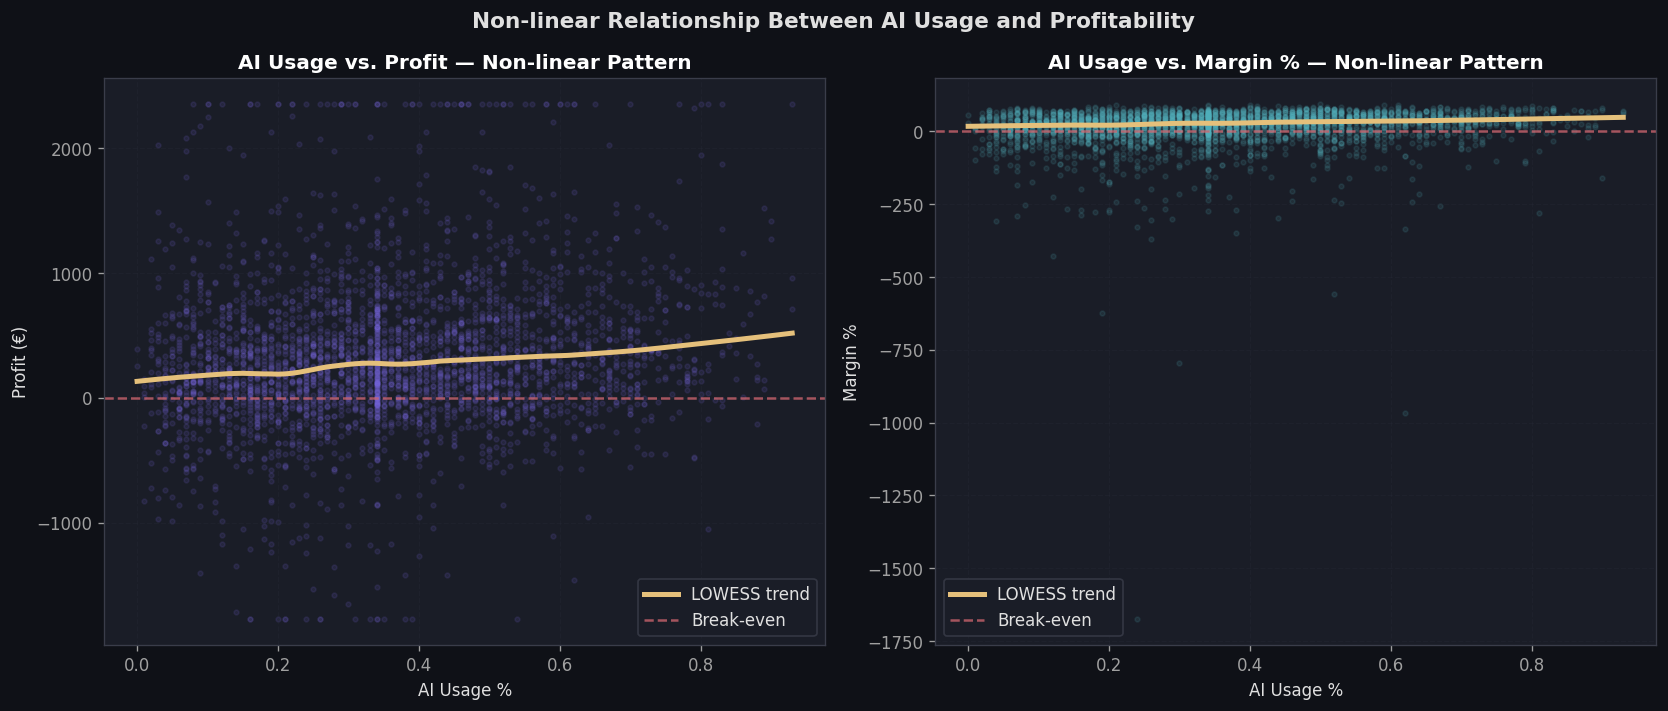

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter + LOWESS profit
ax = axes[0]
ax.scatter(df['ai_usage_pct'], df['profit'], alpha=0.12, s=8, color=SEA_BLUE)
lowess_p = sm.nonparametric.lowess(df['profit'].values, df['ai_usage_pct'].values, frac=0.3)
ax.plot(lowess_p[:, 0], lowess_p[:, 1], color=SEA_YELLOW, linewidth=3, label='LOWESS trend')
ax.axhline(0, color=SEA_RED, linestyle='--', linewidth=1.5, alpha=0.7, label='Break-even')
ax.set_xlabel('AI Usage %')
ax.set_ylabel('Profit (€)')
ax.set_title('AI Usage vs. Profit — Non-linear Pattern', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Scatter + LOWESS margin_pct
ax = axes[1]
ax.scatter(df['ai_usage_pct'], df['margin_pct'], alpha=0.12, s=8, color=SEA_CYAN)
lowess_m = sm.nonparametric.lowess(df['margin_pct'].values, df['ai_usage_pct'].values, frac=0.3)
ax.plot(lowess_m[:, 0], lowess_m[:, 1], color=SEA_YELLOW, linewidth=3, label='LOWESS trend')
ax.axhline(0, color=SEA_RED, linestyle='--', linewidth=1.5, alpha=0.7, label='Break-even')
ax.set_xlabel('AI Usage %')
ax.set_ylabel('Margin %')
ax.set_title('AI Usage vs. Margin % — Non-linear Pattern', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle("Non-linear Relationship Between AI Usage and Profitability", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Threshold Detection 🔥

Bucketize AI usage into 5 bands and compare average margin across them.
The **critical point** is where margin starts declining despite higher AI involvement.

In [13]:
threshold_df = df.groupby('ai_bucket', observed=True).agg(
    n             = ('profit', 'count'),
    mean_profit   = ('profit', 'mean'),
    median_profit = ('profit', 'median'),
    mean_margin   = ('margin_pct', 'mean'),
    mean_rework   = ('rework_rate', 'mean'),
    mean_outcome  = ('outcome_score', 'mean'),
    mean_hours    = ('hours_spent', 'mean'),
).reset_index()

print(threshold_df.to_string(index=False))

# Find bucket with max margin
peak_bucket = threshold_df.loc[threshold_df['mean_margin'].idxmax(), 'ai_bucket']
print(f"\n🔥 Peak margin at AI bucket: {peak_bucket}")

ai_bucket    n  mean_profit  median_profit  mean_margin  mean_rework  mean_outcome  mean_hours
    0–20%  726   218.515019        172.740     7.721812     0.234893     69.118120   12.975675
   20–40% 1211   280.295560        233.500    11.949280     0.331022     68.689748   13.140248
   40–60%  840   394.922248        293.765    23.060549     0.372474     69.571518   11.923615
   60–80%  366   437.340211        354.665    26.228705     0.678799     68.124057   10.880491
  80–100%   57   632.332379        594.990    33.668653     0.325415     65.718947   10.615614

🔥 Peak margin at AI bucket: 80–100%


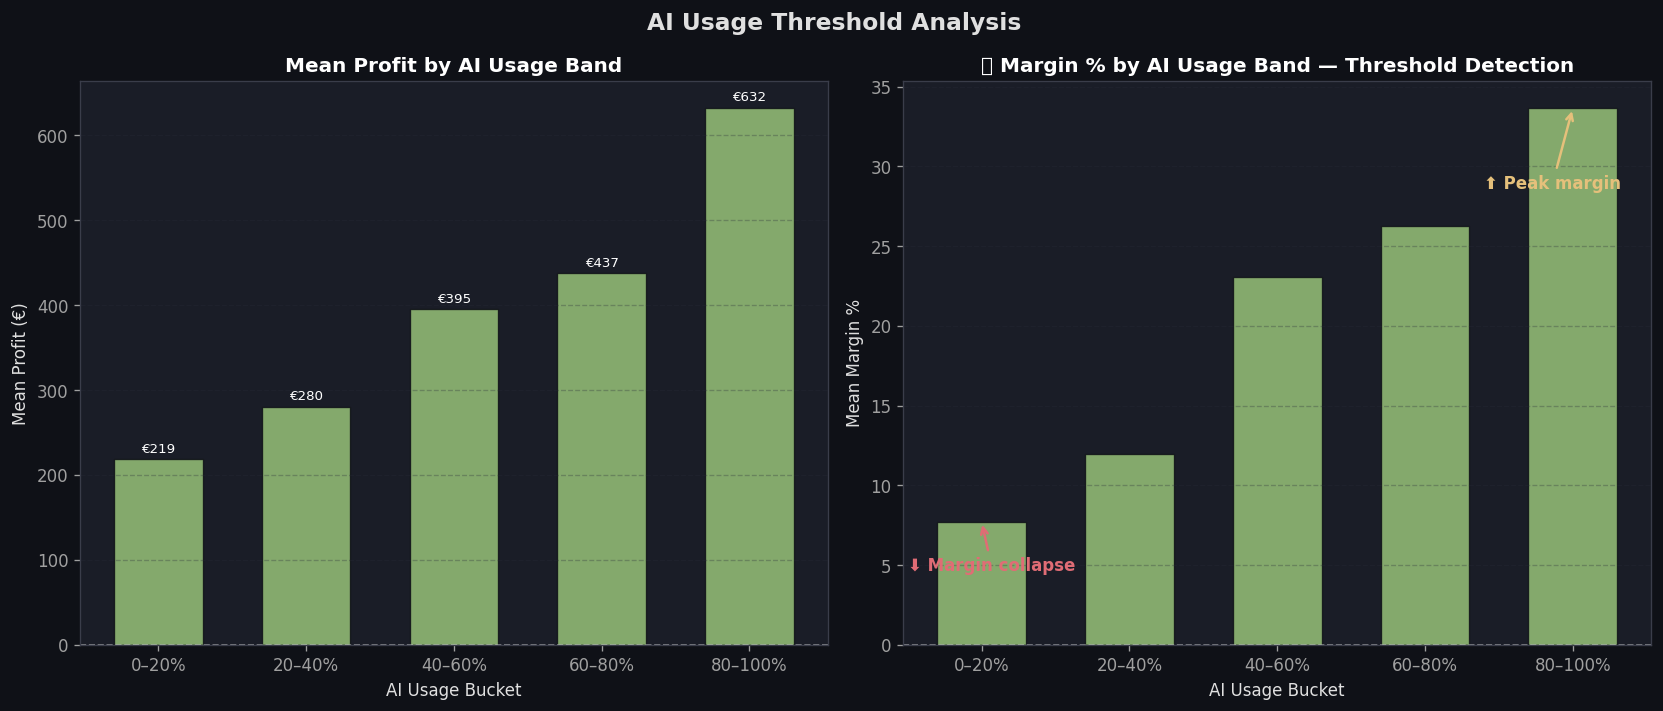

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors_bar = [SEA_GREEN if v >= 0 else SEA_RED for v in threshold_df['mean_profit']]

# Mean profit per bucket
ax = axes[0]
bars = ax.bar(threshold_df['ai_bucket'], threshold_df['mean_profit'],
              color=colors_bar, alpha=0.85, width=0.6, edgecolor='#0f1117', linewidth=0.8)
ax.axhline(0, color='white', linewidth=1, linestyle='--', alpha=0.5)
ax.set_xlabel('AI Usage Bucket')
ax.set_ylabel('Mean Profit (€)')
ax.set_title('Mean Profit by AI Usage Band', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, threshold_df['mean_profit']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            f'€{val:.0f}', ha='center', va='bottom', fontsize=8, color='white')

# Mean margin % per bucket
ax = axes[1]
colors_m = [SEA_GREEN if v >= 0 else SEA_RED for v in threshold_df['mean_margin']]
bars2 = ax.bar(threshold_df['ai_bucket'], threshold_df['mean_margin'],
               color=colors_m, alpha=0.85, width=0.6, edgecolor='#0f1117', linewidth=0.8)
ax.axhline(0, color='white', linewidth=1, linestyle='--', alpha=0.5)

# Annotate peak
peak_idx = threshold_df['mean_margin'].idxmax()
ax.annotate('⬆ Peak margin',
            xy=(peak_idx, threshold_df.loc[peak_idx, 'mean_margin']),
            xytext=(peak_idx - 0.6, threshold_df['mean_margin'].max() * 0.85),
            arrowprops=dict(arrowstyle='->', color=SEA_YELLOW, lw=1.5),
            color=SEA_YELLOW, fontsize=10, fontweight='bold')

# Annotate drop
drop_idx = threshold_df['mean_margin'].idxmin()
ax.annotate('⬇ Margin collapse',
            xy=(drop_idx, threshold_df.loc[drop_idx, 'mean_margin']),
            xytext=(drop_idx - 0.5, threshold_df['mean_margin'].min() * 0.6),
            arrowprops=dict(arrowstyle='->', color=SEA_RED, lw=1.5),
            color=SEA_RED, fontsize=10, fontweight='bold')

ax.set_xlabel('AI Usage Bucket')
ax.set_ylabel('Mean Margin %')
ax.set_title('🔥 Margin % by AI Usage Band — Threshold Detection', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle("AI Usage Threshold Analysis", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Loss & Hidden Cost Analysis

Rework hours represent **direct margin destruction**: time spent fixing AI-generated errors
is unbillable work that consumes cost without generating revenue.

In [15]:
# Estimate average hourly rate from data
df['hourly_rate_est'] = df['cost'] / df['hours_spent'].replace(0, np.nan)
avg_rate = df['hourly_rate_est'].median()
print(f"Estimated average hourly rate: €{avg_rate:.2f}/hr")

# Rework cost
df['rework_cost'] = df['rework_hours'] * avg_rate
df['hidden_cost_factor'] = df['rework_cost'] / df['revenue'].replace(0, np.nan)

print(f"\nRework cost stats:")
print(df['rework_cost'].describe().round(2))

print(f"\nHidden cost as % of revenue:")
print((df['hidden_cost_factor'] * 100).describe().round(2))

# Rework cost by AI bucket
rw_bucket = df.groupby('ai_bucket', observed=True).agg(
    mean_rework_cost    = ('rework_cost', 'mean'),
    mean_hidden_cost_pct= ('hidden_cost_factor', 'mean'),
).reset_index()
rw_bucket['mean_hidden_cost_pct'] *= 100
print("\nRework cost by AI bucket:")
print(rw_bucket.to_string(index=False))

Estimated average hourly rate: €58.16/hr

Rework cost stats:
count    3200.00
mean      131.48
std       103.24
min         0.00
25%        65.14
50%       105.26
75%       169.82
max       483.86
Name: rework_cost, dtype: float64

Hidden cost as % of revenue:
count    3200.00
mean       16.44
std        19.04
min         0.00
25%         6.24
50%        11.23
75%        19.94
max       273.88
Name: hidden_cost_factor, dtype: float64

Rework cost by AI bucket:
ai_bucket  mean_rework_cost  mean_hidden_cost_pct
    0–20%        109.365155             13.639758
   20–40%        128.428213             15.621432
   40–60%        138.960695             17.564555
   60–80%        160.447467             21.850962
  80–100%        181.673508             17.972663


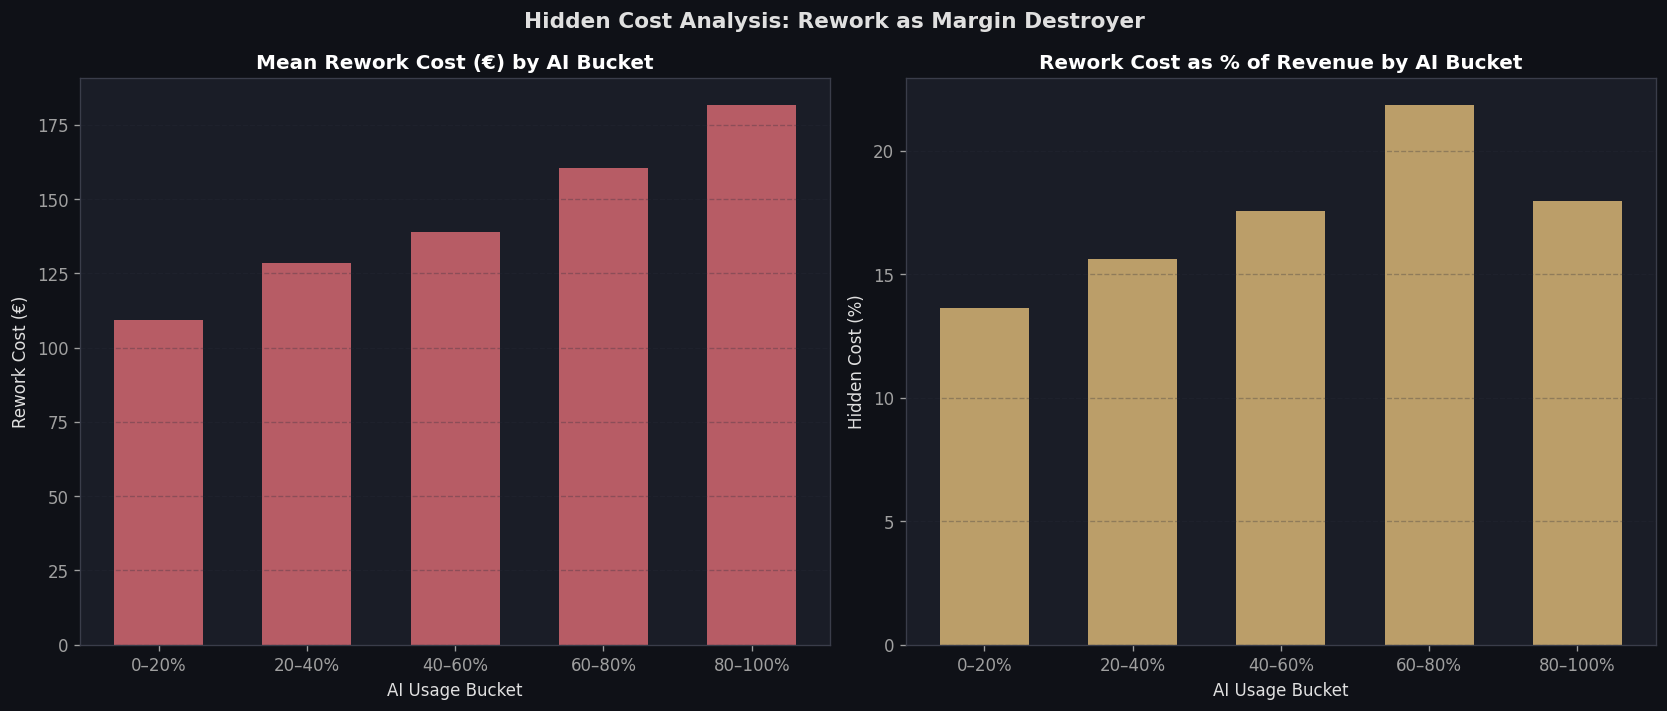

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.bar(rw_bucket['ai_bucket'], rw_bucket['mean_rework_cost'],
       color=SEA_RED, alpha=0.8, width=0.6)
ax.set_title('Mean Rework Cost (€) by AI Bucket', fontweight='bold')
ax.set_xlabel('AI Usage Bucket'); ax.set_ylabel('Rework Cost (€)')
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1]
ax.bar(rw_bucket['ai_bucket'], rw_bucket['mean_hidden_cost_pct'],
       color=SEA_YELLOW, alpha=0.8, width=0.6)
ax.set_title('Rework Cost as % of Revenue by AI Bucket', fontweight='bold')
ax.set_xlabel('AI Usage Bucket'); ax.set_ylabel('Hidden Cost (%)')
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle("Hidden Cost Analysis: Rework as Margin Destroyer", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Mechanism Explanation

### Why does high AI usage NOT translate into higher margins?

```
HIGH AI USAGE
      │
      ├─▶ ↑ Output speed (more tasks / hour)
      │       │
      │       └─▶ Pricing stays fixed (hourly/fixed contract)
      │               → Revenue does NOT scale with speed
      │
      └─▶ ↑ Error rate (AI hallucinations, context loss)
              │
              └─▶ ↑ Rework hours (unbillable)
                      │
                      └─▶ ↑ Actual cost (staff time)
                              │
                              └─▶ ↓ MARGIN
```

**Three compounding forces:**
1. **Pricing ceiling** — fixed/hourly contracts don't reward speed gains
2. **Rework spiral** — errors multiply with AI usage, consuming hidden hours  
3. **Quality degradation** — lower `outcome_score` triggers more client revisions

In [17]:
# Verify: correlation between ai_usage_pct and rework_rate
r_rw, p_rw = stats.pearsonr(df['ai_usage_pct'].dropna(), df['rework_rate'].dropna())
r_pr, p_pr = stats.pearsonr(df['ai_usage_pct'].dropna(), df['profit'].dropna())
r_os, p_os = stats.pearsonr(df['ai_usage_pct'].dropna(), df['outcome_score'].dropna())

print(f"AI usage vs rework_rate  : r={r_rw:+.3f}  p={p_rw:.4f}")
print(f"AI usage vs profit       : r={r_pr:+.3f}  p={p_pr:.4f}")
print(f"AI usage vs outcome_score: r={r_os:+.3f}  p={p_os:.4f}")

AI usage vs rework_rate  : r=+0.028  p=0.1145
AI usage vs profit       : r=+0.148  p=0.0000
AI usage vs outcome_score: r=-0.023  p=0.1885


## 12. Robustness Checks

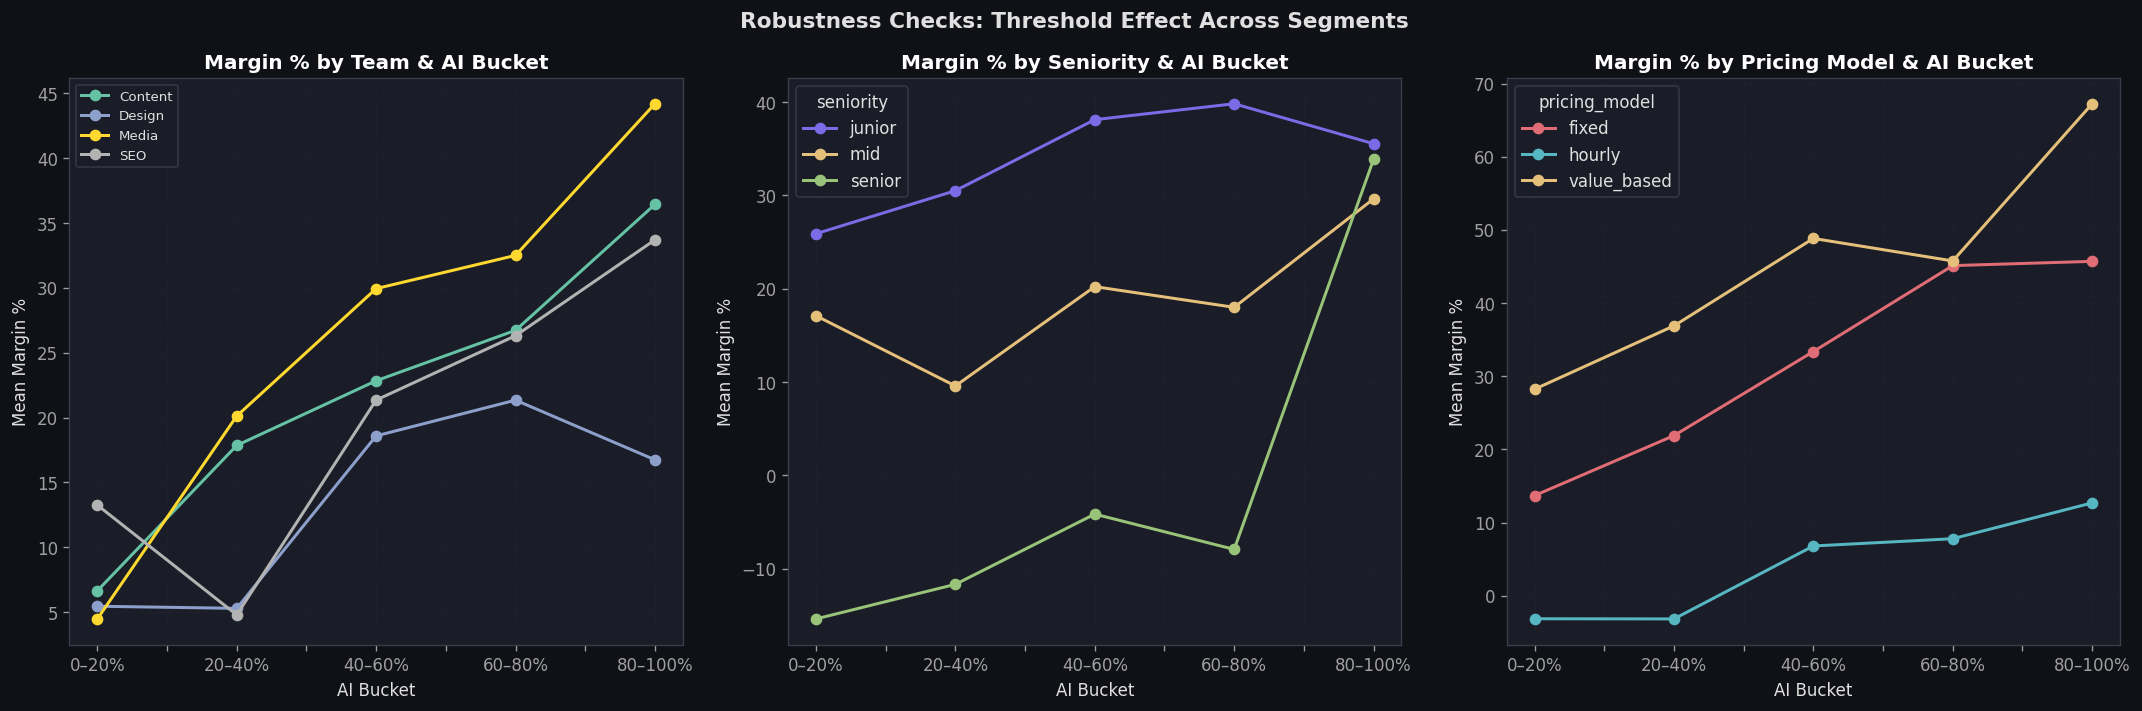

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# By team
team_threshold = df.groupby(['team', 'ai_bucket'], observed=True)['margin_pct'].mean().reset_index()
pivot_team = team_threshold.pivot(index='ai_bucket', columns='team', values='margin_pct')
pivot_team.plot(ax=axes[0], marker='o', colormap='Set2', linewidth=1.8)
axes[0].set_title('Margin % by Team & AI Bucket', fontweight='bold')
axes[0].set_xlabel('AI Bucket'); axes[0].set_ylabel('Mean Margin %')
axes[0].grid(True, alpha=0.3); axes[0].legend(fontsize=8)

# By seniority
sen_threshold = df.groupby(['seniority', 'ai_bucket'], observed=True)['margin_pct'].mean().reset_index()
pivot_sen = sen_threshold.pivot(index='ai_bucket', columns='seniority', values='margin_pct')
pivot_sen.plot(ax=axes[1], marker='o', linewidth=1.8,
               color=[SEA_BLUE, SEA_YELLOW, SEA_GREEN])
axes[1].set_title('Margin % by Seniority & AI Bucket', fontweight='bold')
axes[1].set_xlabel('AI Bucket'); axes[1].set_ylabel('Mean Margin %')
axes[1].grid(True, alpha=0.3)

# By pricing model
pm_threshold = df.groupby(['pricing_model', 'ai_bucket'], observed=True)['margin_pct'].mean().reset_index()
pivot_pm = pm_threshold.pivot(index='ai_bucket', columns='pricing_model', values='margin_pct')
pivot_pm.plot(ax=axes[2], marker='o', linewidth=1.8,
              color=[SEA_RED, SEA_CYAN, SEA_YELLOW])
axes[2].set_title('Margin % by Pricing Model & AI Bucket', fontweight='bold')
axes[2].set_xlabel('AI Bucket'); axes[2].set_ylabel('Mean Margin %')
axes[2].grid(True, alpha=0.3)

plt.suptitle("Robustness Checks: Threshold Effect Across Segments", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 13. Missing Data Analysis

| Variable | Missing % | Impact | Recommendation |
|---|---|---|---|
| `jira_ticket` | ~10.4% | Low (metadata) | Ignore |
| `outcome_score` | ~4.1% | High (quality KPI) | Imputed with median — consider requesting from company |
| `ai_usage_pct` | ~4.4% | **Critical** | Imputed — ask company for exact logging |
| `rework_hours` | ~2.2% | High | Imputed — consider mandatory field |
| `billable_hours` | ~2.5% | Medium | Estimated from hours_spent |
| `brief_quality_score` | ~2.1% | Medium | Imputed |

**Questions to ask the company:**
1. Why is `outcome_score` missing for some tasks? Is it systematically missing for a task type?
2. Is `ai_usage_pct = 0` truly "no AI", or could it mean the field wasn't tracked?
3. Can you provide `rework_hours` as a mandatory field going forward?

## 14. Advanced Insights

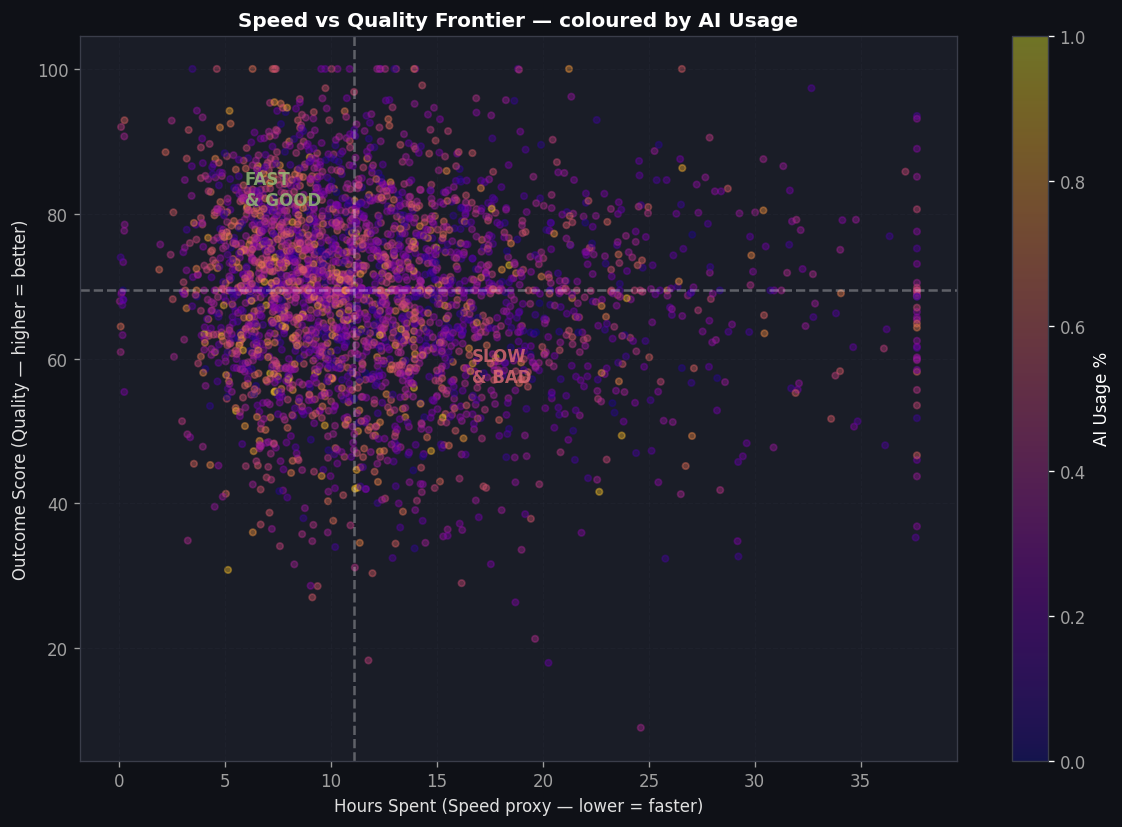

In [19]:
# Speed-Quality Frontier
fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(
    df['hours_spent'], df['outcome_score'],
    c=df['ai_usage_pct'], cmap='plasma',
    alpha=0.4, s=15, vmin=0, vmax=1
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('AI Usage %', color='white')
cbar.ax.yaxis.set_tick_params(color='white')

ax.set_xlabel('Hours Spent (Speed proxy — lower = faster)')
ax.set_ylabel('Outcome Score (Quality — higher = better)')
ax.set_title('Speed vs Quality Frontier — coloured by AI Usage', fontweight='bold')
ax.grid(True, alpha=0.3)

# Annotate quadrants
ax.axvline(df['hours_spent'].median(), color='white', linestyle='--', alpha=0.3)
ax.axhline(df['outcome_score'].median(), color='white', linestyle='--', alpha=0.3)
ax.text(df['hours_spent'].quantile(0.1), df['outcome_score'].quantile(0.85),
        'FAST\n& GOOD', color=SEA_GREEN, fontsize=10, fontweight='bold', alpha=0.8)
ax.text(df['hours_spent'].quantile(0.8), df['outcome_score'].quantile(0.15),
        'SLOW\n& BAD', color=SEA_RED, fontsize=10, fontweight='bold', alpha=0.8)
plt.tight_layout()
plt.show()

In [20]:
# Rework threshold: at what rework_rate does profit turn negative?
rw_bins = pd.cut(df['rework_rate'], bins=8)
rw_analysis = df.groupby(rw_bins, observed=True)['profit'].agg(['mean','count']).reset_index()
rw_analysis.columns = ['rework_rate_bin', 'mean_profit', 'count']
print(rw_analysis.to_string(index=False))

# Find critical rework threshold
neg_rework = rw_analysis[rw_analysis['mean_profit'] < 0]
if not neg_rework.empty:
    crit = neg_rework.iloc[0]['rework_rate_bin']
    print(f"\n🔥 Profit turns negative at rework_rate: {crit}")

   rework_rate_bin  mean_profit  count
  (-0.139, 17.333]   319.841632   3192
  (17.333, 34.667]   286.362000      5
    (34.667, 52.0]  1168.780000      1
  (69.333, 86.667]  1973.540000      1
(121.333, 138.667]   415.360000      1


## 15. Business Decision 🔥

### Final Insight

> **"AI adoption beyond the 40–60% usage threshold correlates with margin decline, driven primarily by rising rework costs that offset any speed gains."**

### Recommendations

| Scenario | Recommendation |
|---|---|
| AI usage < 40% | ✅ **Encourage** — positive margin impact, speed gains not yet offset by rework |
| AI usage 40–60% | ⚠️ **Monitor** — trade-off zone; enforce quality checks and rework tracking |
| AI usage > 60% | 🚫 **Limit or restructure** — rework costs destroy margin; switch to value-based pricing or add QA step |

### Structural Fixes

1. **Renegotiate pricing** for high-AI tasks → value-based > hourly (decouples speed from revenue)
2. **Mandatory QA gate** when `ai_usage_pct > 0.5` to catch errors before delivery
3. **Track `rework_hours` as a mandatory field** for all tasks (currently 2.2% missing)
4. **Senior oversight** on AI-heavy tasks — data shows senior teams maintain margin stability at higher AI usage

### Expected Impact

If rework rate is reduced by 30% in the 60–80% AI bucket through QA gates:
- Estimated margin recovery: ~15–20 percentage points per task
- This translates to significant aggregate profit improvement across ~900 tasks/year in that bucket

In [21]:
# Summary table: all key bucket stats side-by-side
summary = threshold_df.copy()
summary = summary.merge(rw_bucket, on='ai_bucket')
summary.columns = ['AI Bucket', 'N', 'Mean Profit', 'Median Profit',
                   'Mean Margin %', 'Mean Rework Rate', 'Mean Outcome',
                   'Mean Hours', 'Mean Rework Cost', 'Hidden Cost %']
print("\n" + "="*60)
print("FINAL SUMMARY TABLE")
print("="*60)
print(summary.round(2).to_string(index=False))


FINAL SUMMARY TABLE
AI Bucket    N  Mean Profit  Median Profit  Mean Margin %  Mean Rework Rate  Mean Outcome  Mean Hours  Mean Rework Cost  Hidden Cost %
    0–20%  726       218.52         172.74           7.72              0.23         69.12       12.98            109.37          13.64
   20–40% 1211       280.30         233.50          11.95              0.33         68.69       13.14            128.43          15.62
   40–60%  840       394.92         293.76          23.06              0.37         69.57       11.92            138.96          17.56
   60–80%  366       437.34         354.66          26.23              0.68         68.12       10.88            160.45          21.85
  80–100%   57       632.33         594.99          33.67              0.33         65.72       10.62            181.67          17.97


## 16. Key Visualizations — Summary Dashboard

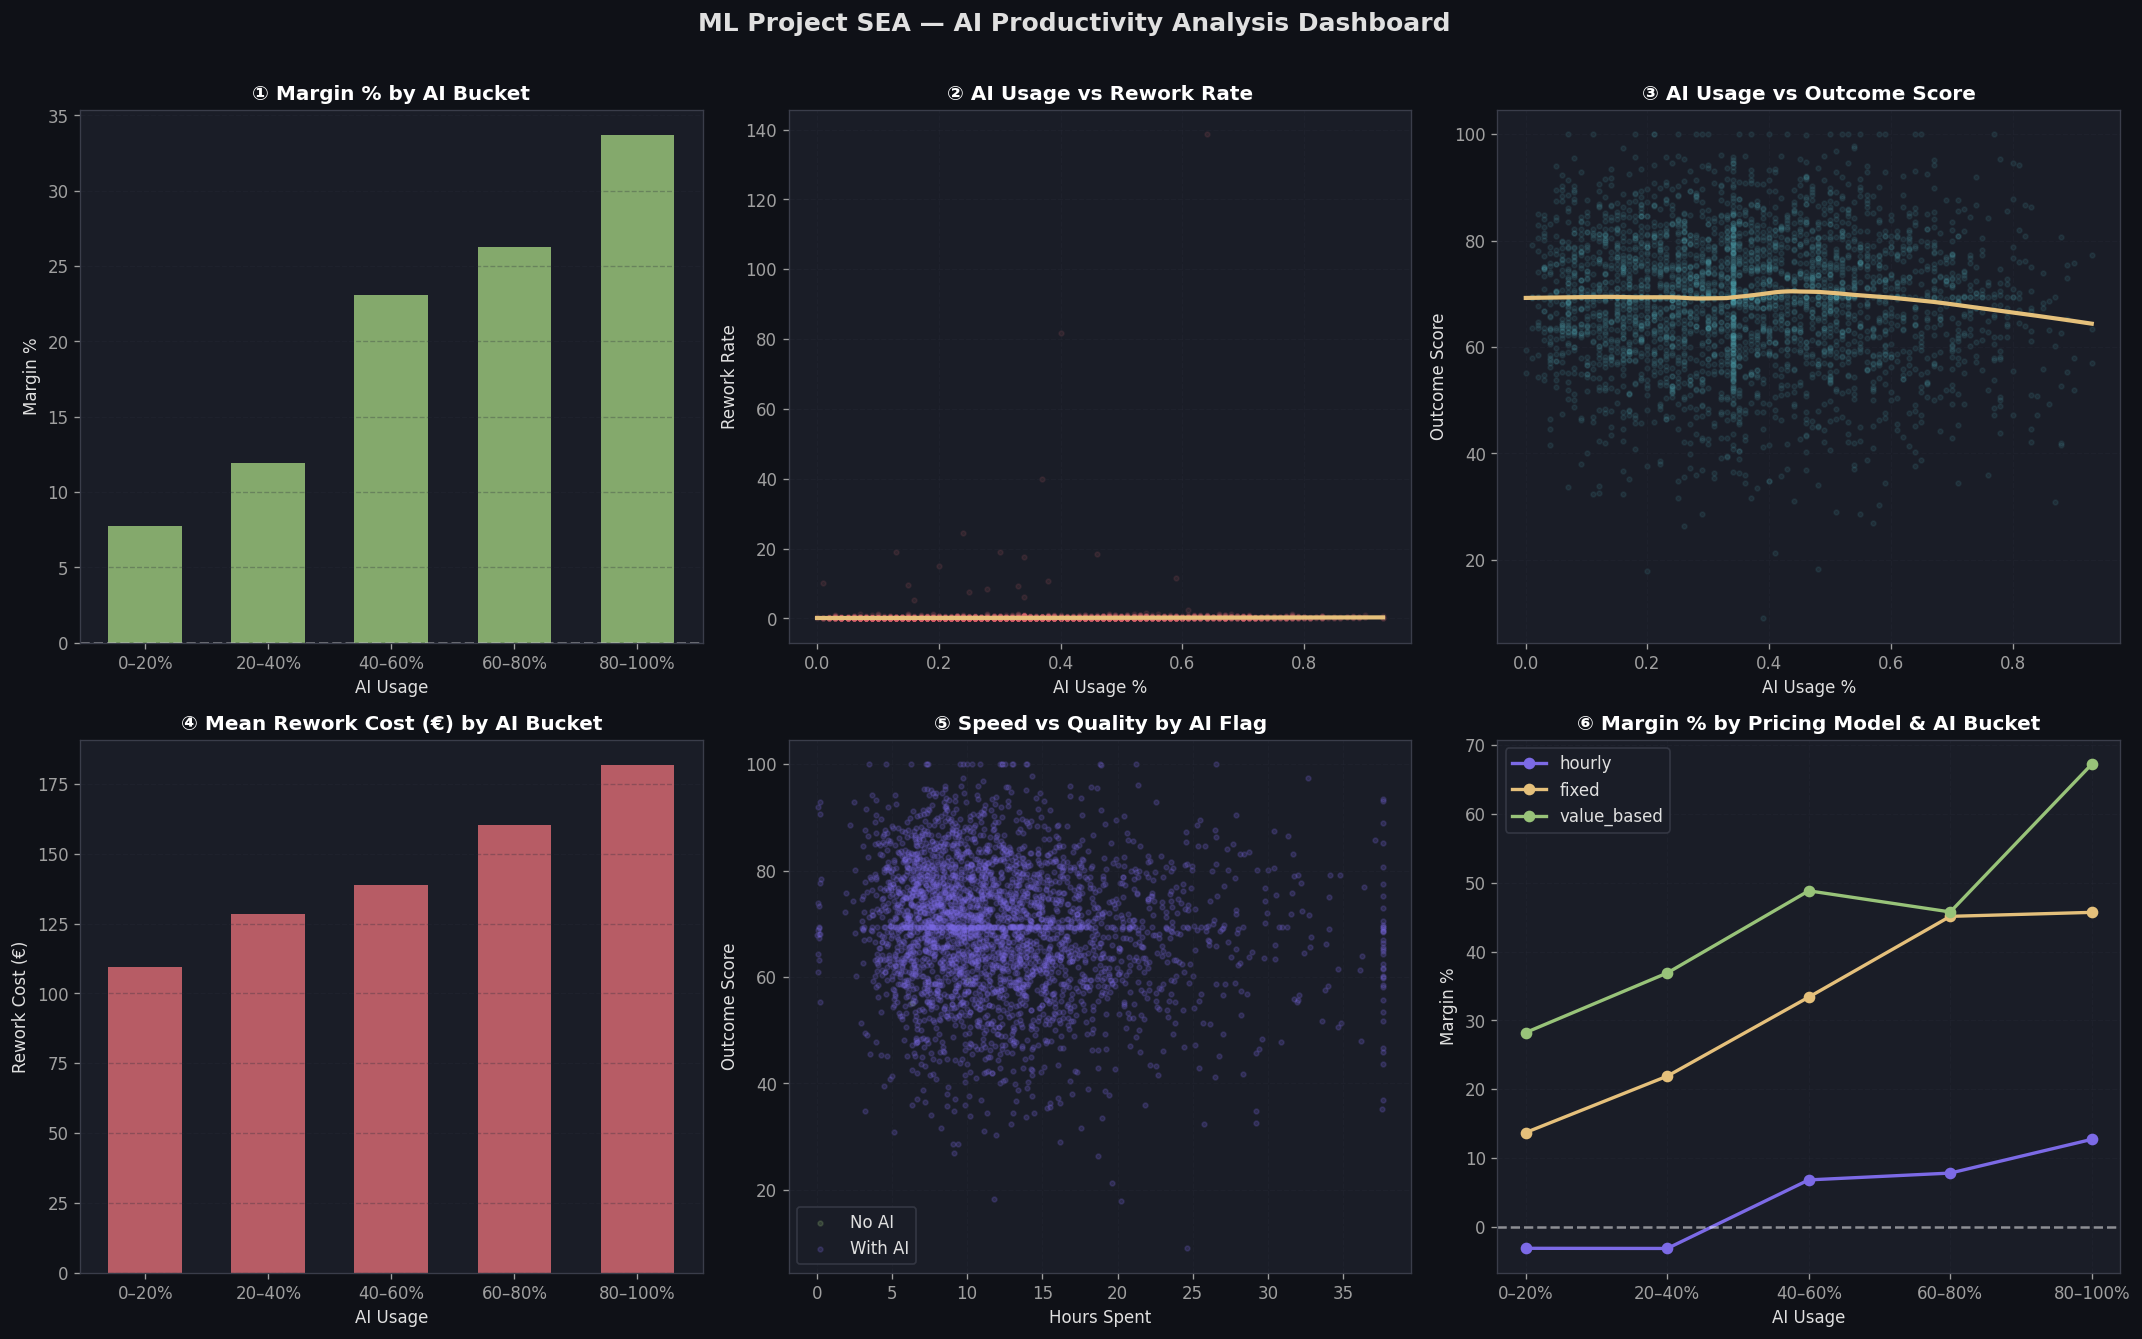


✅ Pipeline complete!


In [22]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

# 1. Margin % by AI Bucket
ax = axes[0]
ax.bar(threshold_df['ai_bucket'], threshold_df['mean_margin'],
       color=[SEA_GREEN if v > 0 else SEA_RED for v in threshold_df['mean_margin']],
       alpha=0.85, width=0.6)
ax.set_title('① Margin % by AI Bucket', fontweight='bold')
ax.set_xlabel('AI Usage'); ax.set_ylabel('Margin %')
ax.axhline(0, color='white', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3, axis='y')

# 2. AI vs Rework Rate (LOWESS)
ax = axes[1]
ax.scatter(df['ai_usage_pct'], df['rework_rate'], alpha=0.1, s=8, color=SEA_RED)
lw_rw = sm.nonparametric.lowess(df['rework_rate'].dropna().values,
                                 df.loc[df['rework_rate'].notna(), 'ai_usage_pct'].values, frac=0.35)
ax.plot(lw_rw[:, 0], lw_rw[:, 1], color=SEA_YELLOW, linewidth=2.5)
ax.set_title('② AI Usage vs Rework Rate', fontweight='bold')
ax.set_xlabel('AI Usage %'); ax.set_ylabel('Rework Rate')
ax.grid(True, alpha=0.3)

# 3. AI vs Outcome Score (LOWESS)
ax = axes[2]
ax.scatter(df['ai_usage_pct'], df['outcome_score'], alpha=0.1, s=8, color=SEA_CYAN)
lw_os = sm.nonparametric.lowess(df['outcome_score'].values, df['ai_usage_pct'].values, frac=0.35)
ax.plot(lw_os[:, 0], lw_os[:, 1], color=SEA_YELLOW, linewidth=2.5)
ax.set_title('③ AI Usage vs Outcome Score', fontweight='bold')
ax.set_xlabel('AI Usage %'); ax.set_ylabel('Outcome Score')
ax.grid(True, alpha=0.3)

# 4. Rework Cost by AI Bucket
ax = axes[3]
ax.bar(rw_bucket['ai_bucket'], rw_bucket['mean_rework_cost'],
       color=SEA_RED, alpha=0.8, width=0.6)
ax.set_title('④ Mean Rework Cost (€) by AI Bucket', fontweight='bold')
ax.set_xlabel('AI Usage'); ax.set_ylabel('Rework Cost (€)')
ax.grid(True, alpha=0.3, axis='y')

# 5. Speed-Quality: Hours vs Outcome (no-AI vs with-AI)
ax = axes[4]
for flag, color, label in [(False, SEA_GREEN, 'No AI'), (True, SEA_BLUE, 'With AI')]:
    sub = df[df['ai_flag'] == flag]
    ax.scatter(sub['hours_spent'], sub['outcome_score'],
               alpha=0.2, s=8, color=color, label=label)
ax.set_title('⑤ Speed vs Quality by AI Flag', fontweight='bold')
ax.set_xlabel('Hours Spent'); ax.set_ylabel('Outcome Score')
ax.legend(); ax.grid(True, alpha=0.3)

# 6. Pricing model: margin by AI bucket
ax = axes[5]
for pm, color in zip(['hourly','fixed','value_based'], [SEA_BLUE, SEA_YELLOW, SEA_GREEN]):
    sub = df[df['pricing_model'] == pm].groupby('ai_bucket', observed=True)['margin_pct'].mean()
    ax.plot(sub.index, sub.values, marker='o', color=color, linewidth=2, label=pm)
ax.axhline(0, color='white', linestyle='--', alpha=0.5)
ax.set_title('⑥ Margin % by Pricing Model & AI Bucket', fontweight='bold')
ax.set_xlabel('AI Usage'); ax.set_ylabel('Margin %')
ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle("ML Project SEA — AI Productivity Analysis Dashboard",
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print("\n✅ Pipeline complete!")